In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("All imports successful")

TensorFlow version: 2.21.0
All imports successful


In [2]:
# Define paths
TRAIN_DIR = '../data/raw/Training'
TEST_DIR = '../data/raw/Testing'

# Count images per class
for split, path in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
    print(f"\n{split} set:")
    total = 0
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            total += count
            print(f"  {cls}: {count} images")
    print(f"  Total: {total}")


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  Total: 5600

Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  Total: 1600


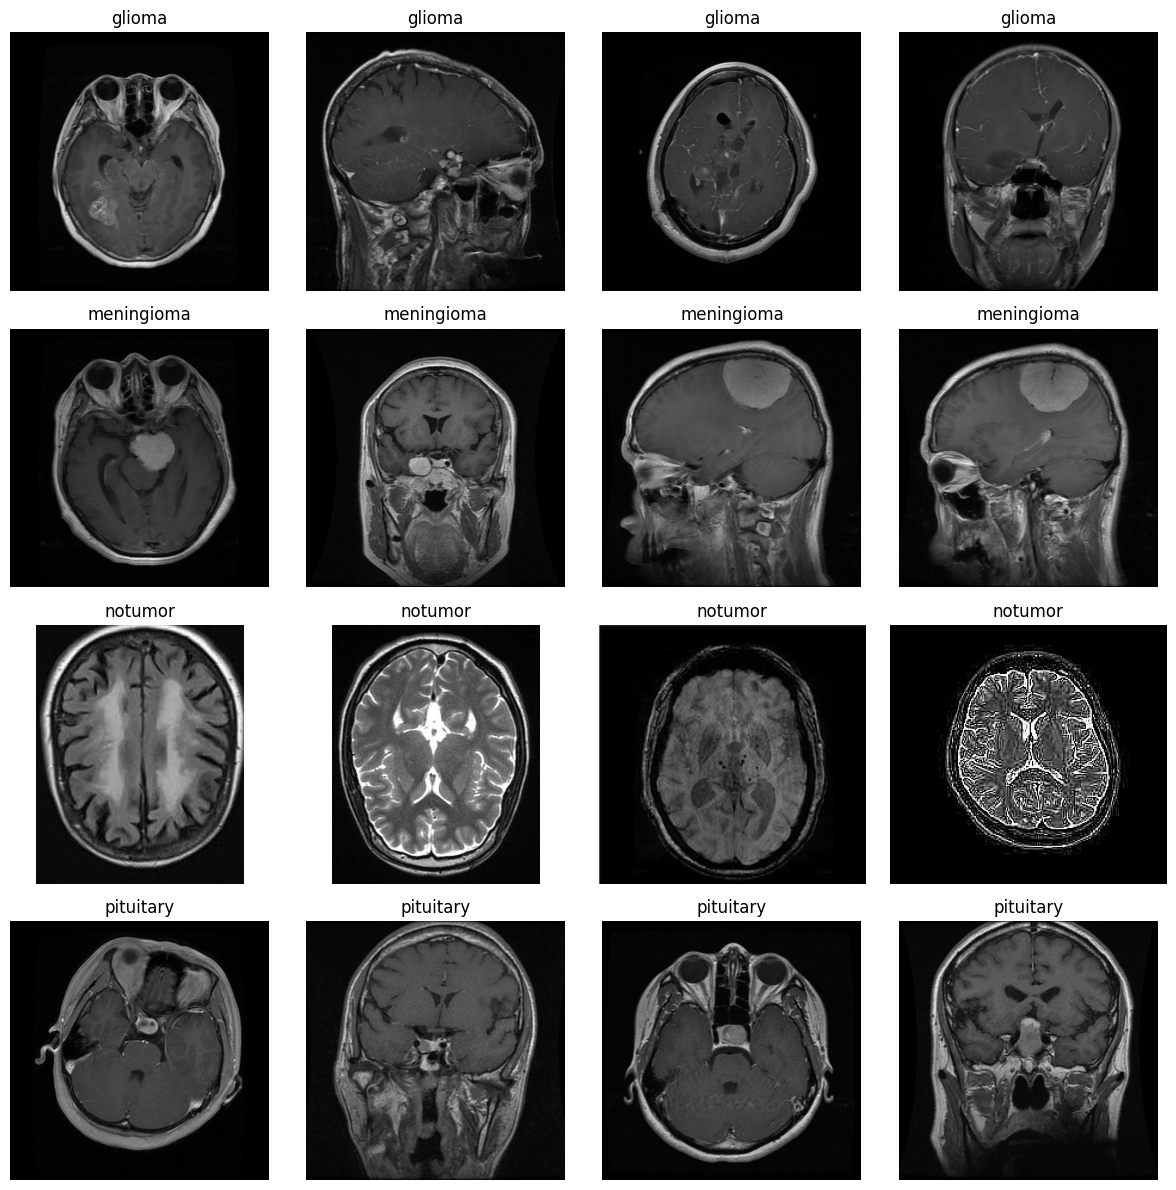

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for row, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = plt.imread(img_path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../results/figures/sample_images.png')
plt.show()

In [4]:
from PIL import Image

# Check image sizes across classes
print("Sample image sizes:\n")
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_name))
    print(f"{cls}: {img.size} | mode: {img.mode}")
    

Sample image sizes:

glioma: (512, 512) | mode: L
meningioma: (512, 512) | mode: L
notumor: (201, 251) | mode: RGB
pituitary: (512, 512) | mode: L


In [5]:
# Check for size variation within each class
print("Size variations per class:\n")
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    sizes = set()
    for img_name in os.listdir(cls_path):
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.add(img.size)
    print(f"{cls}: {len(sizes)} unique sizes")

Size variations per class:

glioma: 1 unique sizes
meningioma: 116 unique sizes
notumor: 250 unique sizes
pituitary: 27 unique sizes


In [6]:
# Summary of findings
print("=== Data Exploration Summary ===")
print(f"\nTraining images: 5,600 (1,400 per class)")
print(f"Testing images: 1,600 (400 per class)")
print(f"Dataset is perfectly balanced — no class imbalance issue")
print(f"\nImage modes: Mixed (grayscale + RGB)")
print(f"Fix: Convert all images to RGB during preprocessing")
print(f"\nImage sizes: Highly variable (especially meningioma and notumor)")
print(f"Fix: Resize all images to 224x224 during preprocessing")
print(f"\nVisual inspection: Sample images saved to results/figures/sample_images.png")

=== Data Exploration Summary ===

Training images: 5,600 (1,400 per class)
Testing images: 1,600 (400 per class)
Dataset is perfectly balanced — no class imbalance issue

Image modes: Mixed (grayscale + RGB)
Fix: Convert all images to RGB during preprocessing

Image sizes: Highly variable (especially meningioma and notumor)
Fix: Resize all images to 224x224 during preprocessing

Visual inspection: Sample images saved to results/figures/sample_images.png
